In [1]:
import cv2
import numpy as np
import csv
import os
from datetime import datetime
from keras.models import load_model

In [14]:
classifier = cv2.CascadeClassifier(
    "haarcascade_frontalface_default (1).xml"
)

model = load_model("final_model.h5")

print("New face detector and model loaded successfully!")

New face detector and model loaded successfully!


In [16]:
labels = ['Sapna', 'Simran', 'dibya']

print("Registered persons:", labels)

Registered persons: ['Sapna', 'Simran', 'dibya']


In [17]:
def preprocess(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (100, 100))
    img = cv2.equalizeHist(img)
    img = img.reshape(1, 100, 100, 1)
    img = img / 255.0
    return img

In [18]:
def mark_attendance(name):
    now = datetime.now()

    date = now.strftime("%Y-%m-%d")
    time = now.strftime("%H:%M:%S")

    # Create attendance.csv if it doesn't exist
    if not os.path.exists("attendance.csv"):
        with open("attendance.csv", "w", newline="") as file:
            writer = csv.writer(file)

            writer.writerow([
                "Name",
                "Date",
                "Time",
                "Status"
            ])

    # Check if the person is already present today
    with open("attendance.csv", "r", newline="") as file:
        reader = csv.DictReader(file)

        for row in reader:
            if row["Name"] == name and row["Date"] == date:
                return False

    # Mark attendance
    with open("attendance.csv", "a", newline="") as file:
        writer = csv.writer(file)

        writer.writerow([
            name,
            date,
            time,
            "Present"
        ])

    return True

In [19]:
camera = cv2.VideoCapture(0)

ret, frame = camera.read()

camera.release()

if ret:
    print("Laptop camera image captured successfully!")
    print("Image shape:", frame.shape)
else:
    print("Could not access the laptop camera.")

Laptop camera image captured successfully!
Image shape: (480, 640, 3)


In [20]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

faces = classifier.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

print("Faces detected:", len(faces))

if len(faces) > 0:

    # Select the largest detected face
    x, y, w, h = max(
        faces,
        key=lambda f: f[2] * f[3]
    )

    face = frame[y:y+h, x:x+w]

    processed_face = preprocess(face)

    prediction = model.predict(
        processed_face,
        verbose=0
    )[0]

    predicted_class = np.argmax(prediction)

    name = labels[predicted_class]

    confidence = float(prediction[predicted_class]) * 100

    print("Recognized person:", name)
    print("Confidence:", round(confidence, 2), "%")

Faces detected: 1
Recognized person: Sapna
Confidence: 100.0 %


In [29]:
if len(faces) > 0:

    if confidence >= 70:
        result = mark_attendance(name)

        if result:
            print("✅ Attendance marked for", name)
        else:
            print("ℹ️", name, "is already marked present today.")

    else:
        print("❌ Confidence too low. Attendance not marked.")

❌ Confidence too low. Attendance not marked.


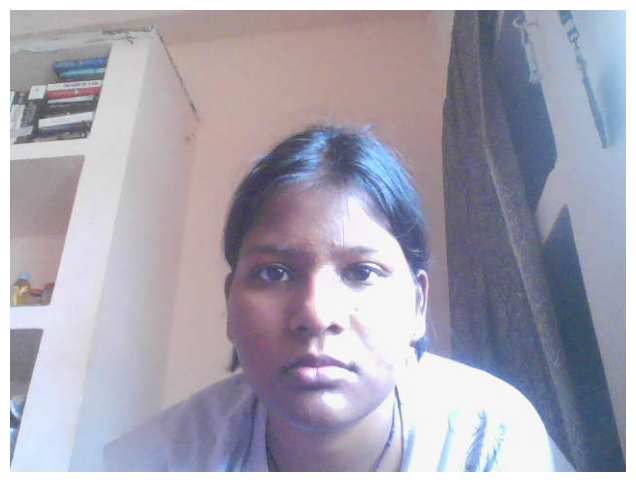

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [12]:
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

faces = classifier.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=3,
    minSize=(50, 50)
)

print("Number of faces detected:", len(faces))

Number of faces detected: 2


In [23]:
for x, y, w, h in faces:
    face = frame[y:y+h, x:x+w]

    processed_face = preprocess(face)

    prediction = model.predict(processed_face, verbose=0)

    predicted_class = np.argmax(prediction)

    name = labels[predicted_class]

    confidence = np.max(prediction)

    print("Recognized:", name)
    print("Confidence:", round(float(confidence) * 100, 2), "%")

Recognized: Sapna
Confidence: 100.0 %
